# AeroNet Lite - Anomaly Classifier

Module 5 notebook: classify drone telemetry into one of
`Normal`, `BatteryAnomaly`, `RouteAnomaly`, `SensorSpike`.

Uses synthetic telemetry generated by `src.ml_pipeline.generate_synthetic_telemetry` so the notebook runs out-of-the-box.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.ml_pipeline import (
    ANOMALY_CLASSES,
    TELEMETRY_FEATURES,
    generate_synthetic_telemetry,
)

## 1. Generate synthetic telemetry

In [2]:
df = generate_synthetic_telemetry(n=2000, seed=42)
print(f"Shape: {df.shape}")
print("Class balance:")
print(df["label"].value_counts())
df.head()

Shape: (2000, 6)
Class balance:
label
Normal            1000
BatteryAnomaly     360
RouteAnomaly       360
SensorSpike        280
Name: count, dtype: int64


,battery_drop,speed,route_deviation,altitude_change,speed_change,label
0,1.906976,12.644130,0.597607,1.066310,5.413032,SensorSpike
1,0.199826,13.938938,0.111087,0.132542,0.827255,Normal
2,7.578146,12.449765,0.953993,0.288426,1.267152,BatteryAnomaly
3,0.881041,12.345150,1.022084,0.234367,0.550759,Normal
4,4.765616,11.520772,0.937285,1.025569,1.140941,BatteryAnomaly


## 2. Train/test split

In [3]:
from sklearn.model_selection import train_test_split

label_to_idx = {name: i for i, name in enumerate(ANOMALY_CLASSES)}
X = df[TELEMETRY_FEATURES]
y = df["label"].map(label_to_idx).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train rows: {len(X_train)}  Test rows: {len(X_test)}")

Train rows: 1600  Test rows: 400


## 3. Decision Tree vs Random Forest

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"DecisionTree  accuracy={accuracy_score(y_test, dt_pred):.4f}")
print(f"RandomForest  accuracy={accuracy_score(y_test, rf_pred):.4f}")
print()
print("Random Forest classification report:")
print(classification_report(y_test, rf_pred, target_names=ANOMALY_CLASSES))

DecisionTree  accuracy=1.0000
RandomForest  accuracy=1.0000

Random Forest classification report:
                precision    recall  f1-score   support

        Normal       1.00      1.00      1.00       200
BatteryAnomaly       1.00      1.00      1.00        72
  RouteAnomaly       1.00      1.00      1.00        72
   SensorSpike       1.00      1.00      1.00        56

      accuracy                           1.00       400
     macro avg       1.00      1.00      1.00       400
  weighted avg       1.00      1.00      1.00       400



## 4. Confusion matrix

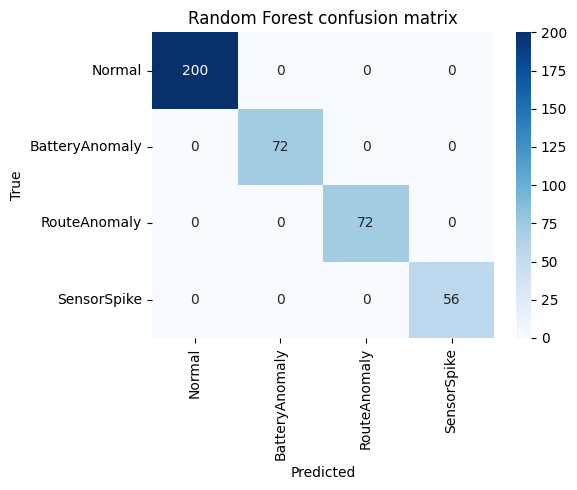

In [5]:
cm = confusion_matrix(y_test, rf_pred, labels=list(range(len(ANOMALY_CLASSES))))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ANOMALY_CLASSES,
    yticklabels=ANOMALY_CLASSES,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Random Forest confusion matrix")
plt.tight_layout()
plt.show()

## 5. Feature importance

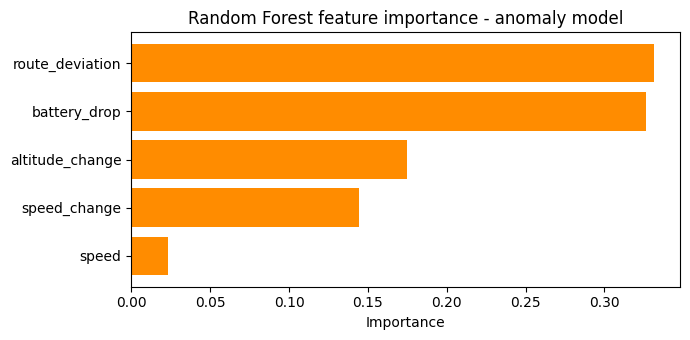

route_deviation    0.331353
battery_drop       0.326095
altitude_change    0.175098
speed_change       0.144281
speed              0.023173
dtype: float64

In [6]:
importances = pd.Series(rf.feature_importances_, index=TELEMETRY_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(importances.index, importances.values, color="darkorange")
ax.set_title("Random Forest feature importance - anomaly model")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)